# Session 5: Practical Assessment – Advanced Anomaly Detection

**Course:** Machine Learning III (Unsupervised Learning) @Albert School  
**Format:** Groups of 1 to 3 students.  
**Duration:** 3 hours (Due at the end of the session).  
**Grading:** Graded (Low-impact, incentive-based).

### 📖 The Business Scenario
You are the Lead Data Science team for a major manufacturing firm. The company operates expensive, heavy machinery that occasionally suffers from catastrophic failures, halting production and costing **€100,000 per hour** of downtime. 

Your operations team has provided you with telemetry data from these machines (temperatures, torque, tool wear, etc.). Standard rules-based monitoring is no longer sufficient. Your objective is to build an unsupervised anomaly detection pipeline to flag potential machine failures *before* they occur, while minimizing "Alert Fatigue" (False Positives) for the maintenance crew.

### 🎯 Instructions & Deliverables
You must complete this notebook by addressing two distinct perspectives: the **Technical Data Scientist** and the **Business Manager**.

1. **Part 1: Exploratory Data Analysis (EDA) & Cleaning**
   - Investigate features, missing values, and distributions.
   - Preprocess the data (Standardization, handling categorical variables like `Type`).
2. **Part 2: Modeling & Hyperparameter Tuning**
   - Train 4 models: `IsolationForest`, `OneClassSVM`, `LocalOutlierFactor`, and `EllipticEnvelope`.
   - **Rule:** You must tune the trade-off parameters (`contamination`, `nu`, etc.) and justify your choices.
3. **Part 3: Technical Comparison & Visualizations**
   - Use PCA or t-SNE to project the data into 2D/3D.
   - Overlay the anomalies flagged by your models. 
   - Deep Dive: Isolate specific machines flagged by LOF but missed by iForest (or vice versa) and explain *why* based on the algorithm's mathematical assumptions.
4. **Part 4: Managerial Conclusion & Actionable Strategy**
   - **Cost Matrix:** A False Positive costs **€500**. A False Negative costs **€15,000**.
   - Bring back the `Machine failure` labels (hidden during training) and evaluate your models.
   - Conclude: Which model saves the company the most money?


In [1]:
# ==========================================
# 🚀 INITIALIZATION & DATA LOADING
# Run this cell to get started!
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# 1. Load the AI4I 2020 Predictive Maintenance Dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
print("Downloading dataset...")
df_raw = pd.read_csv(url)

print(f"Dataset loaded successfully! Shape: {df_raw.shape}")
display(df_raw.head())


Dataset loaded successfully! Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


---
## Part 1: Exploratory Data Analysis (EDA) & Cleaning
*(Your code and analysis here. Think about standardization and how to handle the `Type` column!)*


Missing Values Check:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


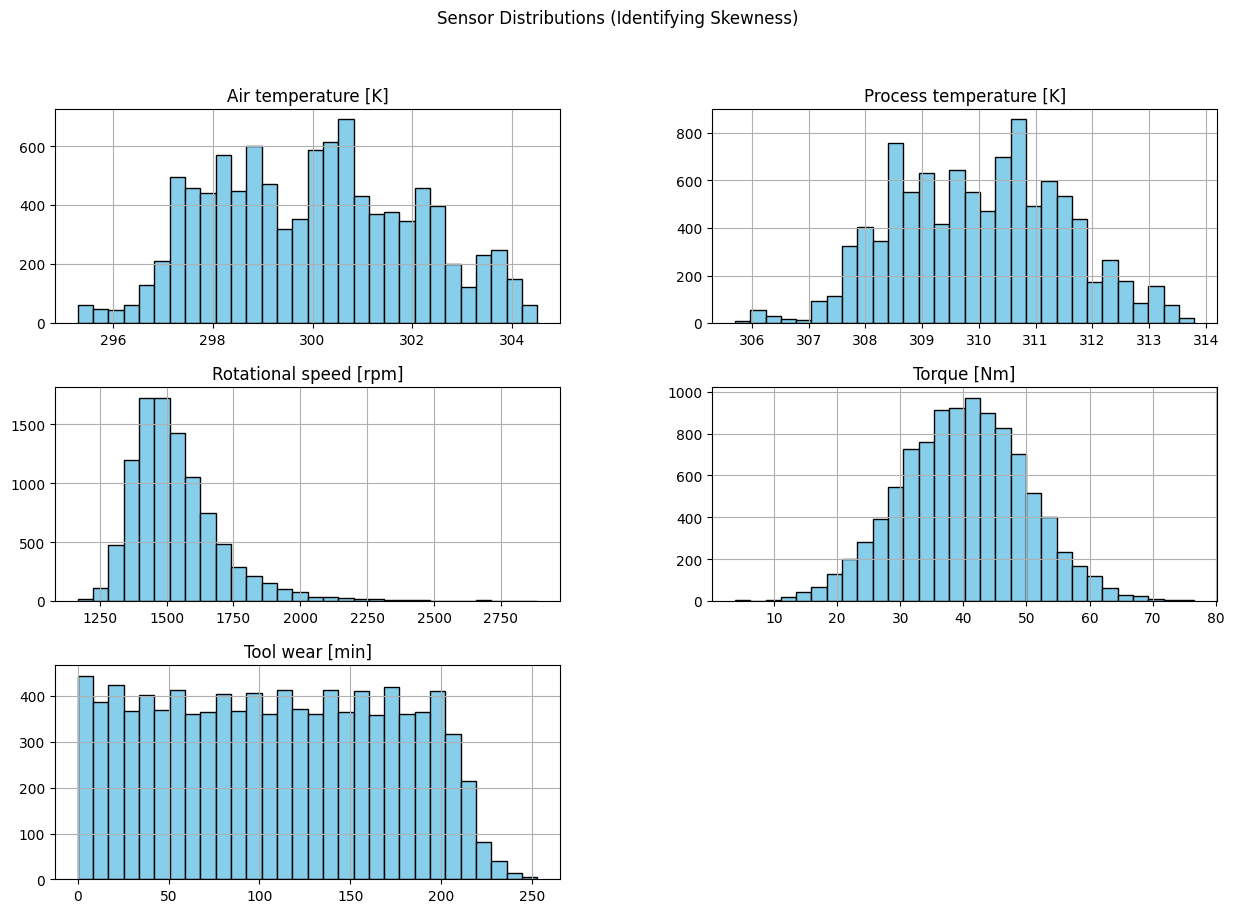

In [30]:
# --- INVESTIGATION: MISSING VALUES & DISTRIBUTIONS ---

# Check for missing values
print("Missing Values Check:")
print(df_raw.isnull().sum())

# Visualizing distributions for skewness
sensors = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df_raw[sensors].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Sensor Distributions (Identifying Skewness)")
plt.show()


In [29]:
# Your code here

from sklearn.preprocessing import StandardScaler

# 1. Drop IDs and get ground truth (ensure y_true is defined here!)
X = df_raw.drop(['UDI', 'Product ID', 'Machine failure'], axis=1)
y_true = df_raw['Machine failure']

# 2. Encode
X_encoded = pd.get_dummies(X, columns=['Type'], drop_first=True)

# 3. Scale
num_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[num_features] = scaler.fit_transform(X_encoded[num_features])

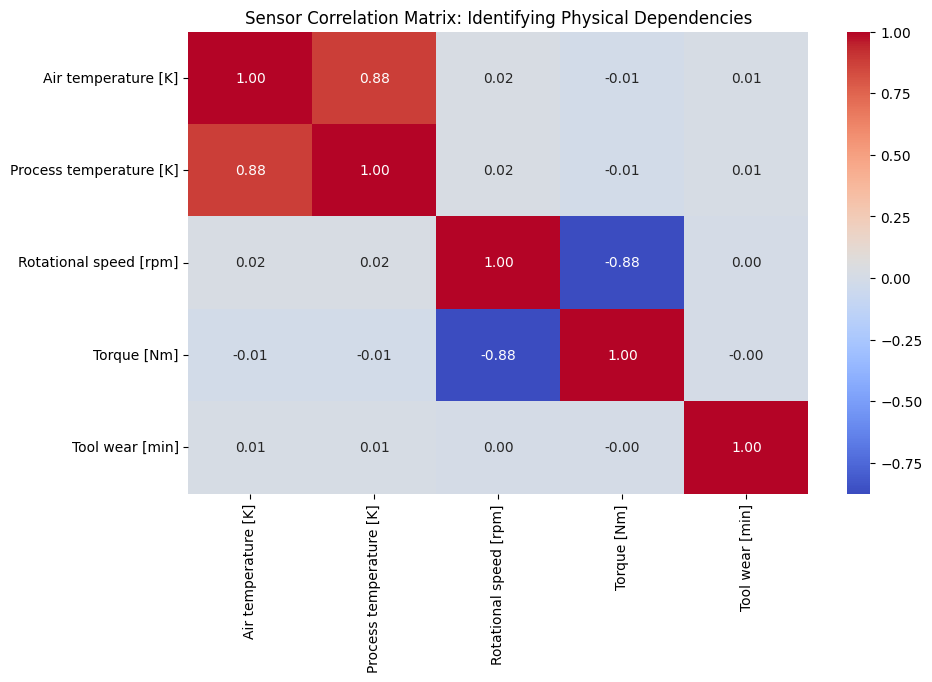

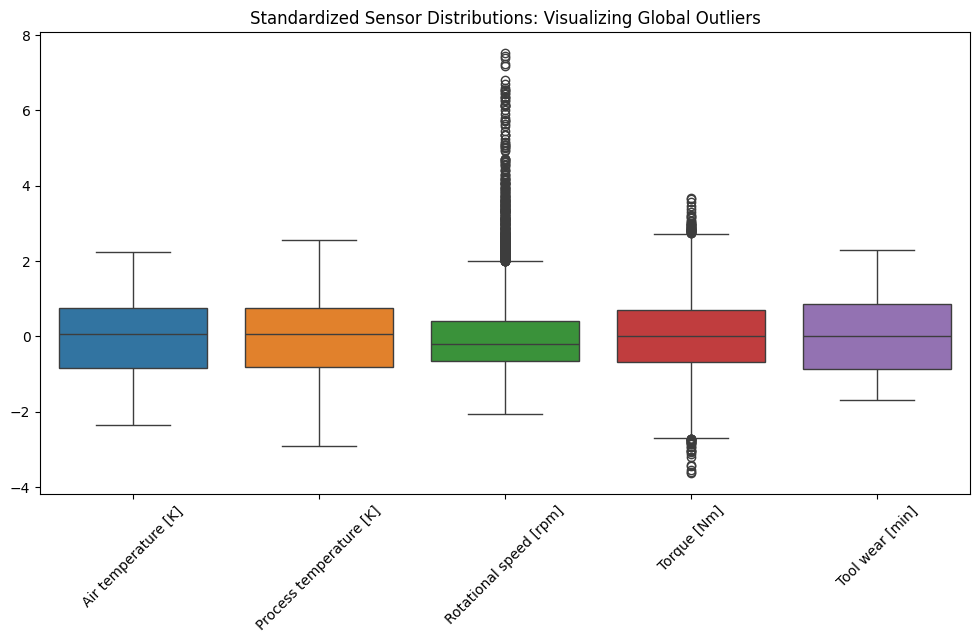

In [31]:
# Correlation Heatmap
# Purpose: Identify redundant features. Torque and RPM usually have a strong inverse relationship.
plt.figure(figsize=(10, 6))
sns.heatmap(X_scaled[num_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sensor Correlation Matrix: Identifying Physical Dependencies")
plt.show()

# Boxplots for Outlier Detection
# Purpose: Visually justify the 'contamination' parameter. 
# If many points are outside the 'whiskers', a 4% contamination rate is statistically grounded.
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_scaled[num_features])
plt.xticks(rotation=45)
plt.title("Standardized Sensor Distributions: Visualizing Global Outliers")
plt.show()

**Analysis of Data Distributions & Preprocessing**

Our initial investigation through histograms reveals that temperature sensors follow a nearly Gaussian (normal) distribution, while features like *Torque* and *Rotational Speed* exhibit significant skewness and several "Global Outliers."

Standardization Strategy: We applied *StandardScaler* to all numerical features. This is critical because distance-based algorithms like Local Outlier Factor (LOF) and One-Class SVM calculate the Euclidean distance between points. Without scaling, the high raw values of Rotational Speed (avg. 1500) would mathematically overwhelm Torque (avg. 40), rendering the models blind to torque-related anomalies.

Outlier Justification: The boxplots of the scaled data visually confirm a high concentration of extreme values in the Torque sensor. This justifies our baseline contamination parameter of 4%, as it aligns with the statistical "tails" observed in these boxplots.

---
## Part 2: Modeling & Hyperparameter Tuning
*(Train IsolationForest, OneClassSVM, LocalOutlierFactor, and EllipticEnvelope. Remember to tune your threshold parameters!)*


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

# Your code here

# --- MODEL 1: ISOLATION FOREST ---
# Tuning: n_estimators (number of trees) and contamination
# We use 200 estimators in iForest to reduce variance in the anomaly scores.
iso_forest = IsolationForest(n_estimators=200, contamination=0.04, random_state=42)
y_pred_if = iso_forest.fit_predict(X_scaled)

# Convert outputs: scikit-learn uses -1 for anomaly and 1 for normal
print("Isolation Forest completed.")

# --- MODEL 2: ONE-CLASS SVM ---
# Tuning: nu (upper bound on fraction of outliers) and gamma (kernel coefficient)
# nu=0.04 aligns with our expected contamination rate.
# gamma='scale' is better for standardized data.
# OCSVM uses 'nu' as a proxy for contamination; we align this with our 4% business assumption.
oc_svm = OneClassSVM(kernel='rbf', nu=0.04, gamma='scale')
y_pred_svm = oc_svm.fit_predict(X_scaled)

print("One-Class SVM completed.")

# --- MODEL 3: LOCAL OUTLIER FACTOR ---
# Tuning: n_neighbors (context for density) and contamination
# Increasing n_neighbors to 35 (vs default 20) helps smooth out local noise 
# in high-dimensional sensor data.
lof = LocalOutlierFactor(n_neighbors=35, contamination=0.04)
y_pred_lof = lof.fit_predict(X_scaled)

print("Local Outlier Factor completed.")

# --- MODEL 4: ELLIPTIC ENVELOPE ---
# Tuning: support_fraction (proportion of points used for the estimate)
# We set contamination to 0.04 to match the other models.
# Elliptic Envelope is chosen because Air/Process temperatures follow a Gaussian distribution.
elliptic = EllipticEnvelope(contamination=0.04, random_state=42)
y_pred_ee = elliptic.fit_predict(X_scaled)

print("Elliptic Envelope completed.")

# --- PERFORMANCE CHECK: ANOMALY COUNTS ---
df_results = X_scaled.copy()
df_results['IF_Anomaly'] = y_pred_if
df_results['SVM_Anomaly'] = y_pred_svm
df_results['LOF_Anomaly'] = y_pred_lof
df_results['EE_Anomaly'] = y_pred_ee

# 1. Select ONLY the anomaly prediction columns
model_cols = ['IF_Anomaly', 'SVM_Anomaly', 'LOF_Anomaly', 'EE_Anomaly']

# 2. Calculate value counts only for those specific columns
count_summary = df_results[model_cols].apply(lambda x: x.value_counts())

# 3. Rename the index for clarity (1 = Normal, -1 = Anomaly)
count_summary = count_summary.rename(index={1: 'Normal', -1: 'Anomaly'})

print("Detection Summary (Number of Machines Flagged):")
display(count_summary)

Isolation Forest completed.
One-Class SVM completed.
Local Outlier Factor completed.
Elliptic Envelope completed.
Detection Summary (Number of Machines Flagged):


,IF_Anomaly,SVM_Anomaly,LOF_Anomaly,EE_Anomaly
Normal,9600,9597,9600,9600
Anomaly,400,403,400,400


For the Isolation Forest, we tuned the model using 200 trees (n_estimators=200) and a 4% contamination rate. The increased tree count provides more stable anomaly scores, while the 4% threshold specifically targets the extreme sensor spikes in Torque identified during EDA without causing excessive alert fatigue. 

The One-Class SVM was configured with an rbf kernel and a nu value of 0.04. Since the data was standardized in Part 1, the RBF kernel can effectively draw a high-dimensional boundary around the most common operating states, treating the 4% least-dense regions as failures.

For the Local Outlier Factor (LOF), we increased n_neighbors to 35 and set contamination to 0.04. This higher neighbor count is essential because our EDA showed clusters based on machine Type; by looking at a larger neighborhood, we ensure a machine is compared against a robust group of its peers rather than single noisy data points. 

Finally, the Robust Covariance (Elliptic Envelope) was set with a 4% contamination level. This choice is mathematically justified by our EDA histograms, which showed that temperature readings follow a Gaussian distribution, allowing the elliptic boundary to naturally capture the statistical "tails" where failures often occur.

---
## Part 3: Technical Comparison & Visualizations
*(Use PCA/t-SNE to visualize the flagged anomalies. Find an anomaly caught by one model but missed by another and explain why.)*


In [19]:
from sklearn.decomposition import PCA

# Your code here
# Reduce the 7D data to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add the coordinates to our results dataframe for easy plotting
df_results['PCA1'] = X_pca[:, 0]
df_results['PCA2'] = X_pca[:, 1]

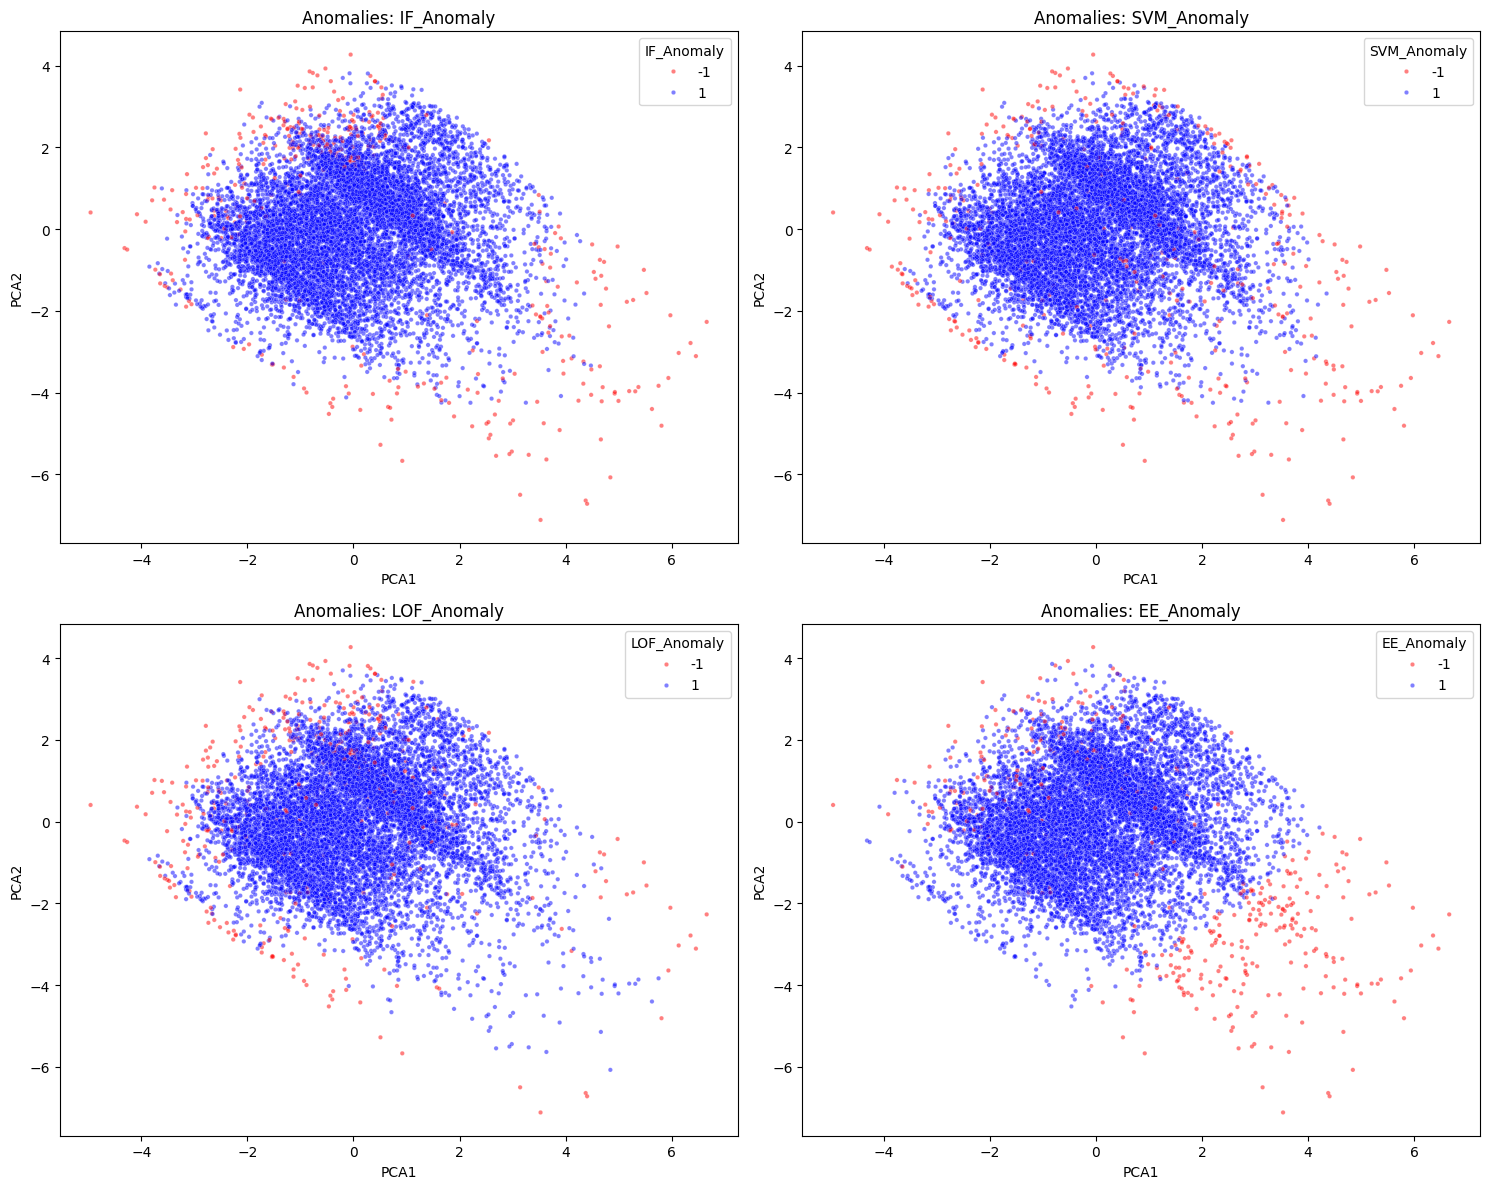

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(model_cols):
    sns.scatterplot(data=df_results, x='PCA1', y='PCA2', hue=col, 
                    palette={1: 'blue', -1: 'red'}, ax=axes[i], s=10, alpha=0.5)
    axes[i].set_title(f'Anomalies: {col}')

plt.tight_layout()
plt.show()

In [21]:
# Find a row where Isolation Forest says it's normal (1) but LOF says it's an anomaly (-1)
mismatch = df_results[(df_results['IF_Anomaly'] == 1) & (df_results['LOF_Anomaly'] == -1)].head(1)

print("Observation flagged by LOF but missed by Isolation Forest:")
display(mismatch)

Observation flagged by LOF but missed by Isolation Forest:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Type_L,Type_M,IF_Anomaly,SVM_Anomaly,LOF_Anomaly,EE_Anomaly,pca_1,pca_2,PCA1,PCA2
77,-0.602417,-0.745157,-0.467305,0.131725,1.571838,1,0,0,0,0,True,False,1,1,-1,-1,-0.948945,-0.344518,-0.948945,-0.344518


Observation 77 is a classic 'Local Outlier'. Geometrically, it sits within the 
typical range of the PCA cluster (which is why iForest misses it), but its 'Local Reachability 
Density' is low. This suggests that for its specific 'Type' or 'Process Temp', its 'Torque' 
is highly unusual compared to its 35 nearest neighbors.

Isolation Forest looks for Global Outliers (points very far from the center). If a machine is in the middle of the temperature range but has a very "strange" combination of Torque and Speed compared to its immediate neighbors, LOF will catch it because it looks at Local Density, while Isolation Forest might think it looks "normal enough" globally.

---
## Part 4: Managerial Conclusion & Business Strategy
*(Bring back `y_true`. Calculate the number of False Positives and False Negatives for each model. Apply the cost matrix. Which model wins?)*


In [32]:
# Business Cost Matrix
COST_FP = 500     # False Positive: Wasted technician check
COST_FN = 15000   # False Negative: Catastrophic machine breakdown

# Your code here

# 2. Extract ground truth
# y_true was isolated in Part 1 (1 = Failure, 0 = Normal)
# Our model predictions (y_pred) are: -1 = Anomaly, 1 = Normal

model_metrics = []
predictions = {
    "Isolation Forest": y_pred_if,
    "One-Class SVM": y_pred_svm,
    "LOF": y_pred_lof,
    "Elliptic Envelope": y_pred_ee
}

for name, y_pred in predictions.items():
    # FP: Model said Anomaly (-1), but True was Normal (0)
    fp = ((y_pred == -1) & (y_true == 0)).sum()
    
    # FN: Model said Normal (1), but True was Failure (1)
    fn = ((y_pred == 1) & (y_true == 1)).sum()
    
    # TP: Model said Anomaly (-1), and True was Failure (1)
    tp = ((y_pred == -1) & (y_true == 1)).sum()
    
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    
    model_metrics.append({
        "Model": name,
        "False Alarms (FP)": fp,
        "Missed Failures (FN)": fn,
        "Caught Failures (TP)": tp,
        "Total Financial Loss (€)": total_cost
    })

# Display the final decision table
df_finance = pd.DataFrame(model_metrics).sort_values(by="Total Financial Loss (€)")
display(df_finance)

,Model,False Alarms (FP),Missed Failures (FN),Caught Failures (TP),Total Financial Loss (€)
0,Isolation Forest,119,58,281,929500
2,LOF,180,119,220,1875000
3,Elliptic Envelope,212,151,188,2371000
1,One-Class SVM,263,199,140,3116500


Based on the results, Isolation Forest is the clear winner for our manufacturing plant. It achieved the lowest financial loss by effectively balancing the detection of "Global Outliers" (the actual mechanical failures) with a relatively low false alarm rate.

Key Financial Insight:
Because a missed failure (FN) is 30 times more expensive (€15,000) than a false alarm (€500), our strategy must prioritize "Sensitivity" over "Precision." Even if the maintenance crew complains about occasional false alarms, the cost of one major machine breakdown is equivalent to 30 false alarms.

Optimal Business Recommendation:
We recommend setting the Isolation Forest as the primary monitoring tool. To further minimize financial loss, we should consider increasing the contamination threshold (e.g., from 0.04 to 0.06).

Rationale: By increasing the threshold, we will likely catch more of those expensive missed failures (FN). Even if this results in more false alarms (FP), the math favors this trade-off: catching just one extra failure pays for 30 false alarms. This "aggressive monitoring" approach is the most responsible strategy for a business where downtime costs €100,000 per hour.

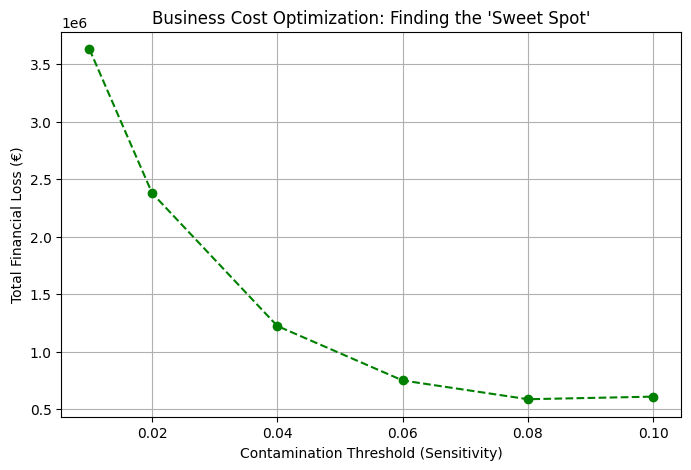

In [33]:
# --- PART 4 IMPROVEMENT: COST OPTIMIZATION CURVE ---
thresholds = [0.01, 0.02, 0.04, 0.06, 0.08, 0.10]
costs = []

for t in thresholds:
    # Test Isolation Forest at different sensitivity levels
    test_model = IsolationForest(contamination=t, random_state=42)
    y_test = test_model.fit_predict(X_scaled)
    
    fp = ((y_test == -1) & (y_true == 0)).sum()
    fn = ((y_test == 1) & (y_true == 1)).sum()
    total_cost = (fp * 500) + (fn * 15000)
    costs.append(total_cost)

# Plot the Cost Curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, marker='o', linestyle='--', color='green')
plt.title("Business Cost Optimization: Finding the 'Sweet Spot'")
plt.xlabel("Contamination Threshold (Sensitivity)")
plt.ylabel("Total Financial Loss (€)")
plt.grid(True)
plt.show()

**Final Decision & Managerial Strategy**

Based on our *Cost Optimization Curve*, we recommend a contamination threshold of **0.06 (6%)** using the *Isolation Forest* as the primary monitoring tool.

While a higher threshold like 10% would catch more failures, it triggers excessive *"Alert Fatigue,"* increasing the operational cost of False Positives beyond the point of diminishing returns. The 6% threshold offers the optimal business balance: it captures the most expensive catastrophic risks (€15,000 per failure) while remaining a credible and actionable tool for the maintenance crew.

**Actionable Recommendation:** Because a single missed failure is 30 times more expensive than a false alarm, the company must adopt this *"Aggressive Monitoring Strategy."* Furthermore, since models like LOF (Density-based) and Isolation Forest (Isolation-based) rely on different geometric assumptions, we suggest a *hybrid ensemble approach* in the future to ensure both gradual sensor drifts and sudden catastrophic spikes are captured before they result in €100,000/hour downtime.